In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import pyarrow
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
import scipy.stats as stats
import plotly.express as px

# Data

In [3]:
features_df = pd.read_parquet(r"..\data\features\features.parquet", engine="pyarrow")

# Data preprocessing

In [4]:
# Mobile mean with a window of one hour
hours = 1
# Apply filters to the time series of the features
features_df = features_df[(features_df['energy']>=0)&(features_df['kurtosis']<2500)&(features_df['frequency_index']>=-3)&(features_df['entropy']>=0)&(features_df['entropy']<15000)]
# Calculate moving average for all features
features_df['energy_mobile_mean'] = np.log10(features_df['energy'].rolling(window=11*hours, center=False).mean())
features_df['kurtosis_mobile_mean'] = np.log10(features_df['kurtosis'].rolling(window=11*hours, center=False).mean())
features_df['frequency_index_mobile_mean'] = features_df['frequency_index'].rolling(window=11*hours, center=False).mean()
features_df['entropy_mobile_mean'] = features_df['entropy'].rolling(window=11*hours, center=False).mean()
features_df['energy'] = np.log10(features_df['energy'])
features_df['kurtosis'] = np.log10(features_df['kurtosis'])

## Training set

In [5]:
features_df_1_month = features_df[features_df['timestamp']<"2022-02-01"]

In [46]:
features_df_1_month.head(50)

,timestamp,energy,kurtosis,frecuency_index,entropy,frequency_index,energy_mobile_mean,kurtosis_mobile_mean,frequency_index_mobile_mean,entropy_mobile_mean
0,2022-01-01 00:05:00,0.849685,-0.197926,None,6743.988806,-0.005959,NaN,NaN,NaN,NaN
1,2022-01-01 00:10:00,0.846348,-0.198750,None,7043.316623,-0.109812,NaN,NaN,NaN,NaN
2,2022-01-01 00:15:00,0.845799,-0.123996,None,7175.473832,0.032564,NaN,NaN,NaN,NaN
3,2022-01-01 00:20:00,0.845747,-0.124835,None,7186.277967,0.065660,NaN,NaN,NaN,NaN
4,2022-01-01 00:25:00,0.844254,-0.135150,None,7290.097859,-0.179743,NaN,NaN,NaN,NaN
5,2022-01-01 00:30:00,0.868000,-0.021163,None,5457.995975,0.070995,NaN,NaN,NaN,NaN
6,2022-01-01 00:35:00,0.866955,-0.015300,None,5535.414736,0.114525,NaN,NaN,NaN,NaN
7,2022-01-01 00:40:00,0.843636,-0.261068,None,7247.518703,-0.038871,NaN,NaN,NaN,NaN
8,2022-01-01 00:45:00,0.870828,0.170143,None,5458.520975,-0.006298,NaN,NaN,NaN,NaN
9,2022-01-01 00:50:00,0.870033,0.177628,None,5551.227111,-0.000272,NaN,NaN,NaN,NaN


In [6]:
# Filter the first eleven observations with NAs values
features_df_1_month = features_df_1_month.dropna(subset=['energy_mobile_mean'])
features_df_1_month.head()

,timestamp,energy,kurtosis,frecuency_index,entropy,frequency_index,energy_mobile_mean,kurtosis_mobile_mean,frequency_index_mobile_mean,entropy_mobile_mean
10,2022-01-01 00:55:00,6.939812,0.711175,None,7546.761724,0.088087,7.189824,1.016756,0.002807,6566.963119
11,2022-01-01 01:00:00,7.223312,1.604005,None,6466.796551,0.406264,7.202035,1.135282,0.040282,6541.763823
12,2022-01-01 01:05:00,7.226848,1.593019,None,6412.502725,0.412137,7.217582,1.225977,0.087732,6484.417105
13,2022-01-01 01:10:00,6.961643,0.591916,None,7359.259713,0.072474,7.214921,1.221882,0.091360,6501.124913
14,2022-01-01 01:15:00,6.911538,0.566936,None,7642.527056,-0.028144,7.209869,1.217271,0.082832,6542.602102


In [7]:
# Take descriptive variables
variables = ["energy_mobile_mean",	"kurtosis_mobile_mean", "frequency_index_mobile_mean", "entropy_mobile_mean"]
X = features_df_1_month[["energy_mobile_mean",	"kurtosis_mobile_mean",	
                         "frequency_index_mobile_mean", "entropy_mobile_mean"]].to_numpy()

print(X.shape)

(8883, 4)


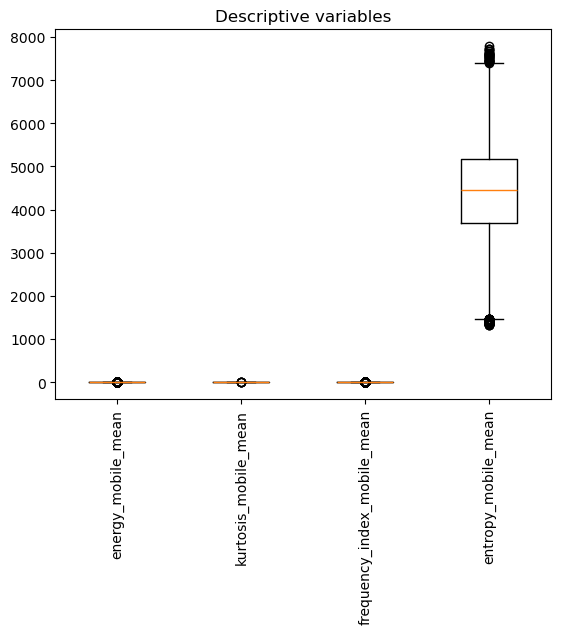

In [11]:
# See distribution of variables
plt.title('Descriptive variables')
plt.boxplot(X)
plt.xticks(ticks=range(1, 5), labels=variables, rotation=90)
plt.show()

In [8]:
# Scale variables
scaler = StandardScaler().fit(X)
X = scaler.transform(X)

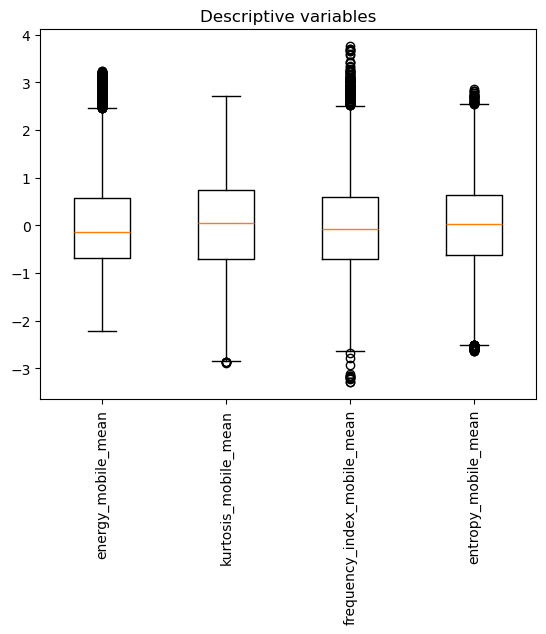

In [13]:
# Plot again
plt.title('Descriptive variables')
plt.boxplot(X)
plt.xticks(ticks=range(1, 5), labels=variables, rotation=90)
plt.show()

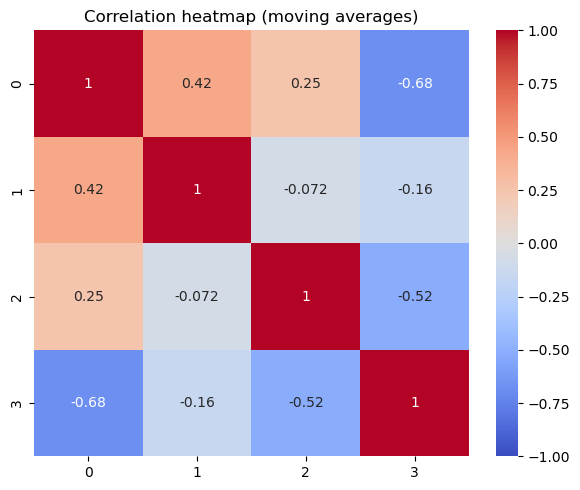

In [ ]:
# Compute correlation matrix
corr = pd.DataFrame(data=X).corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap (moving averages)')
plt.tight_layout()
plt.show()

## Dimensionality reduction

### PCA

In [14]:
# Train a PCA model
pcs = PCA(n_components=4).fit(X)
pcs

PCA(n_components=4)

In [15]:
# Report PCA summary
pcsSummary = pd.DataFrame({'Standard deviation': np.sqrt(pcs.explained_variance_),
                           'Proportion of variance': pcs.explained_variance_ratio_,
                           'Cumulative variance': np.cumsum(pcs.explained_variance_ratio_)})

pcsSummary = pcsSummary.transpose()
pcsSummary.columns = ['PC'+str(ind) for ind in range(1, 5)]
pcsSummary.round(3)

,PC1,PC2,PC3,PC4
Standard deviation,1.550,1.041,0.698,0.164
Proportion of variance,0.601,0.271,0.122,0.007
Cumulative variance,0.601,0.871,0.993,1.000


In [16]:
# See the weights for each PC
pcsComponents = pd.DataFrame(pcs.components_.transpose(),
                             columns=['PC'+str(ind) for ind in range(1, 5)],
                             index= variables)

pcsComponents

,PC1,PC2,PC3,PC4
energy_mobile_mean,0.622870,0.096867,-0.299516,0.716199
kurtosis_mobile_mean,0.198621,0.861159,0.457580,-0.097850
frequency_index_mobile_mean,0.436324,-0.498516,0.749067,0.001221
entropy_mobile_mean,-0.618227,0.022427,0.373910,0.691002


We are interested in the observations that go to the opposite side of the PC1, low values of entropy and high values of energy

In [17]:
# Apply PCA transformation to original data
Z = pd.DataFrame(pcs.transform(X), columns=['PC'+str(ind) for ind in range(1, 5)])
Z

,PC1,PC2,PC3,PC4
0,-2.135400,-0.375789,1.052349,0.168395
1,-1.933740,-0.194296,1.351386,0.147064
2,-1.917360,-0.255189,1.430223,0.153489
3,-1.979965,-0.294824,1.397361,0.164519
4,-2.043222,-0.302861,1.356356,0.173677
...,...,...,...,...
8877,3.309308,-0.411634,0.306021,0.042222
8878,3.531031,-0.156866,0.612026,0.039930
8879,3.425185,-0.213073,0.671566,0.022305
8880,3.183994,-0.427619,0.530310,0.014579


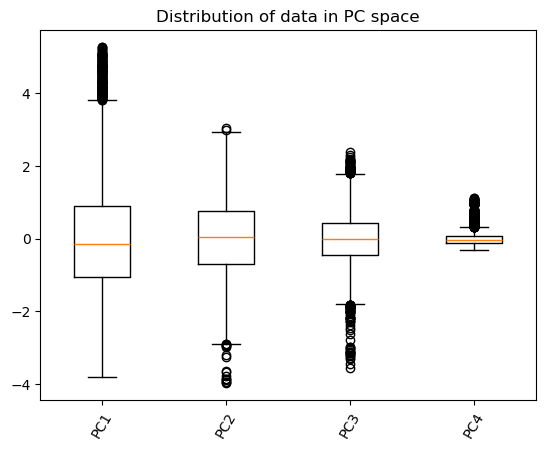

In [18]:
# Plot distribution of data
plt.title('Distribution of data in PC space')
plt.boxplot(pcs.transform(X))
plt.xticks(ticks=range(1, 5), labels=['PC'+str(ind) for ind in range(1, 5)], rotation=60)
plt.show()

### Model with three PC

In [9]:
# Create a PCA object and train it
pca = PCA(n_components=3).fit(X)
# Transform the data to the new reducted space
Z = pca.transform(X)
print(Z.shape)

(8883, 3)


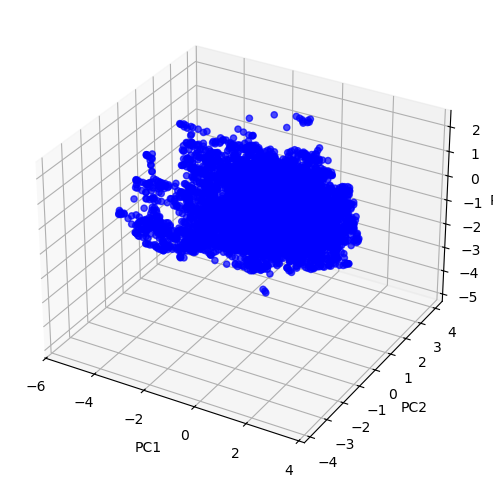

In [12]:
# Plot in the new space
"""
fig = px.scatter_3d(
                    x=Z[:, 0],
                    y=Z[:, 1],
                    z=Z[:, 2],
                    labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3'},
                    title='PCA 3D projection',
                    opacity=0.7
                )
fig.update_traces(marker=dict(size=3))
fig.show()
"""

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c='b', s=20, alpha=0.7)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.grid(True)
plt.show()

#### Clustering

In [13]:
# Try with different number of groups
inertia = []
silh = []
k_s = np.arange(2, 16)
for k in k_s:
  km_model = KMeans(n_clusters=k).fit(Z)
  inertia.append(km_model.inertia_)
  silh.append(silhouette_score(Z, km_model.labels_))

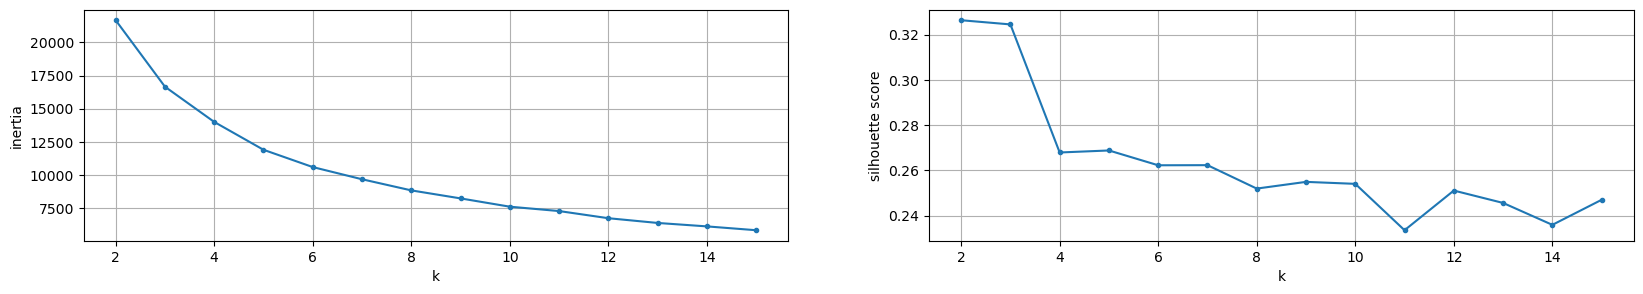

In [14]:
# Plot results
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.plot(k_s, inertia, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('inertia')
plt.subplot(1, 2, 2)
plt.plot(k_s, silh, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.show()

#### Ensemble-based clustering analysis

In [23]:
# Run KMeans multiple times and find the most frequent label for each data point

n_iterations = 1000  # Number of times to run KMeans
n_clusters = 4

# Store labels from each iteration
all_labels = np.zeros((n_iterations, len(Z)), dtype=int)

# Run KMeans multiple times (without fixed random_state to get different initializations)
for i in range(n_iterations):
    km_temp = KMeans(n_clusters=n_clusters, random_state=None, n_init=10).fit(Z)
    all_labels[i, :] = km_temp.labels_
    if (i + 1) % 100 == 0:
        print(f"Completed iteration {i + 1}/{n_iterations}")

# Find the most frequent label for each data point
most_frequent_labels = np.zeros(len(Z), dtype=int)
label_frequencies = np.zeros(len(Z))
label_consistency = np.zeros(len(Z))

for point_idx in range(len(Z)):
    labels_for_point = all_labels[:, point_idx]
    # Get the most common label
    counts = np.bincount(labels_for_point, minlength=n_clusters)
    most_frequent_labels[point_idx] = np.argmax(counts)
    # Calculate frequency and consistency
    label_frequencies[point_idx] = np.max(counts) / n_iterations
    label_consistency[point_idx] = (np.max(counts) - np.sort(counts)[-2]) / n_iterations if n_clusters > 1 else 1.0

print(f"\nLabel frequency statistics:")
print(f"Mean frequency: {label_frequencies.mean():.3f}")
print(f"Min frequency: {label_frequencies.min():.3f}")
print(f"Max frequency: {label_frequencies.max():.3f}")
print(f"\nLabel consistency statistics:")
print(f"Mean consistency: {label_consistency.mean():.3f}")

# Use the most frequent labels as the final clustering result
km_model = KMeans(n_clusters=n_clusters, random_state=42).fit(Z)
km_model.labels_ = most_frequent_labels

Completed iteration 100/1000
Completed iteration 200/1000
Completed iteration 300/1000
Completed iteration 400/1000
Completed iteration 500/1000
Completed iteration 600/1000
Completed iteration 700/1000
Completed iteration 800/1000
Completed iteration 900/1000
Completed iteration 1000/1000

Label frequency statistics:
Mean frequency: 0.310
Min frequency: 0.264
Max frequency: 0.341

Label consistency statistics:
Mean consistency: 0.034


In [24]:
labels = km_model.labels_

fig = px.scatter_3d(
    x=Z[:, 0],
    y=Z[:, 1],
    z=Z[:, 2],
    color=labels,
    labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3', 'color': 'Cluster'},
    title='Principal Components Analysis Plot (Interactive 3D)',
    opacity=0.8,
)
fig.update_traces(marker=dict(size=4))
fig.show()

In [25]:
# Create a dataframe with the clustering data
clustering_data = pd.DataFrame(Z, columns= ['PC1', 'PC2', 'PC3'])
clustering_data['labels'] = km_model.labels_

In [18]:
clustering_data.head()

,PC1,PC2,PC3,labels
0,2.093583,-0.309114,0.587753,0
1,1.867200,-0.188118,0.922386,0
2,1.618884,-0.169109,1.240274,0
3,1.624468,-0.190031,1.254425,0
4,1.677512,-0.163761,1.226588,0


In [26]:
# Create a dataframe with the clustering data
km_model.cluster_centers_ = clustering_data.groupby('labels')[['PC1','PC2', 'PC3']].mean().values

In [20]:
km_model.cluster_centers_

array([[ 0.54499475,  0.05971739],
       [-0.89396806,  0.53783348],
       [-2.0366985 , -1.47914511],
       [-2.20131708,  1.22139346]])

In [27]:
# Clean the data
clustering_data = clustering_data.dropna()

C:\Users\javie\AppData\Local\Temp\ipykernel_9960\4112878207.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


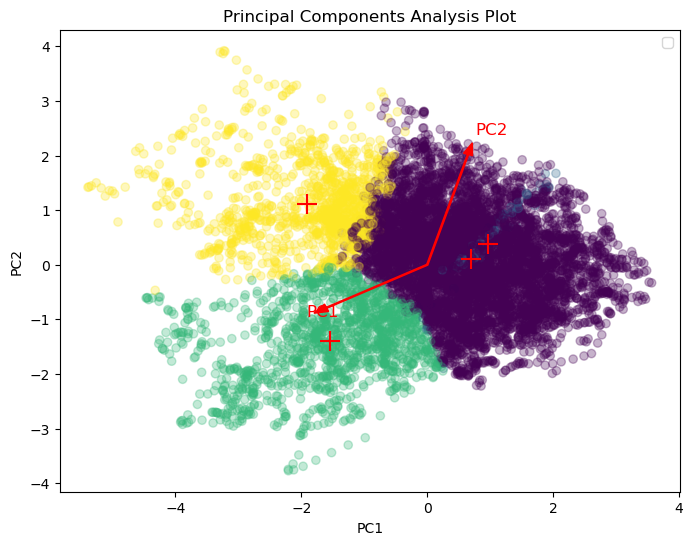

In [28]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(Z[:, 0], Z[:, 1], c=labels, cmap='viridis', alpha=0.3)
plt.scatter(km_model.cluster_centers_[:, 0], km_model.cluster_centers_[:, 1], c='red', s=200, marker='+')
# Plot principal component axes
origin = np.mean(Z[:, :2], axis=0)
for i, (vec, var) in enumerate(zip(pca.components_[:2], pca.explained_variance_ratio_[:2])):
    plt.arrow(origin[0], origin[1], vec[0]*3, vec[1]*3, color='red', width=0.02, head_width=0.15, length_includes_head=True)
    plt.text(origin[0] + vec[0]*3.2, origin[1] + vec[1]*3.2, f'PC{i+1}', color='red', fontsize=12)
plt.title('Principal Components Analysis Plot')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

##### Groups distribution

In [29]:
clustering_data[['labels','PC1']].groupby('labels').count()

,PC1
labels,
0,6219
1,79
2,1414
3,1171


In [43]:
features_df_1_month.tail()

,timestamp,energy,kurtosis,frecuency_index,entropy,frequency_index,energy_mobile_mean,kurtosis_mobile_mean,frequency_index_mobile_mean,entropy_mobile_mean
8892,2022-01-31 23:35:00,8.830721,2.334161,None,1668.982751,0.629002,8.473396,1.545346,0.324982,2175.657356
8893,2022-01-31 23:40:00,8.817154,2.361190,None,1705.372009,0.451853,8.513603,1.728055,0.356279,2153.905901
8894,2022-01-31 23:45:00,8.051987,0.780485,None,2927.230991,0.083474,8.487884,1.726429,0.360435,2241.093051
8895,2022-01-31 23:50:00,7.990021,0.815191,None,3100.668472,0.158434,8.449206,1.681851,0.344058,2342.231222
8896,2022-01-31 23:55:00,7.809566,0.646664,None,3571.532223,0.084493,8.404498,1.625282,0.310173,2478.684310


## Results analysis

In [30]:
data = features_df_1_month[["energy_mobile_mean",	"kurtosis_mobile_mean",	
                         "frequency_index_mobile_mean", "entropy_mobile_mean"]].to_numpy()

# Create a dataframe with the clustering data including the timestamp column and labels
observed_data = pd.DataFrame(data, columns= variables)
observed_data['timestamp'] = features_df_1_month['timestamp']
observed_data['labels'] = km_model.labels_

In [71]:
print(observed_data[observed_data['timestamp'].isna()])

      energy_mobile_mean  kurtosis_mobile_mean  frequency_index_mobile_mean  \
0               7.189824              1.016756                     0.002807   
1               7.202035              1.135282                     0.040282   
2               7.217582              1.225977                     0.087732   
3               7.214921              1.221882                     0.091360   
4               7.209869              1.217271                     0.082832   
5               7.206780              1.214691                     0.095824   
6               7.166144              1.203743                     0.087245   
7               7.124996              1.192086                     0.082709   
8               7.126502              1.196224                     0.100424   
9               7.077612              1.138447                     0.115834   
4149            7.799584              1.311001                     0.041692   
4150            7.807588              1.318502      

Why I have NaT?

In [31]:
observed_data = observed_data.dropna()

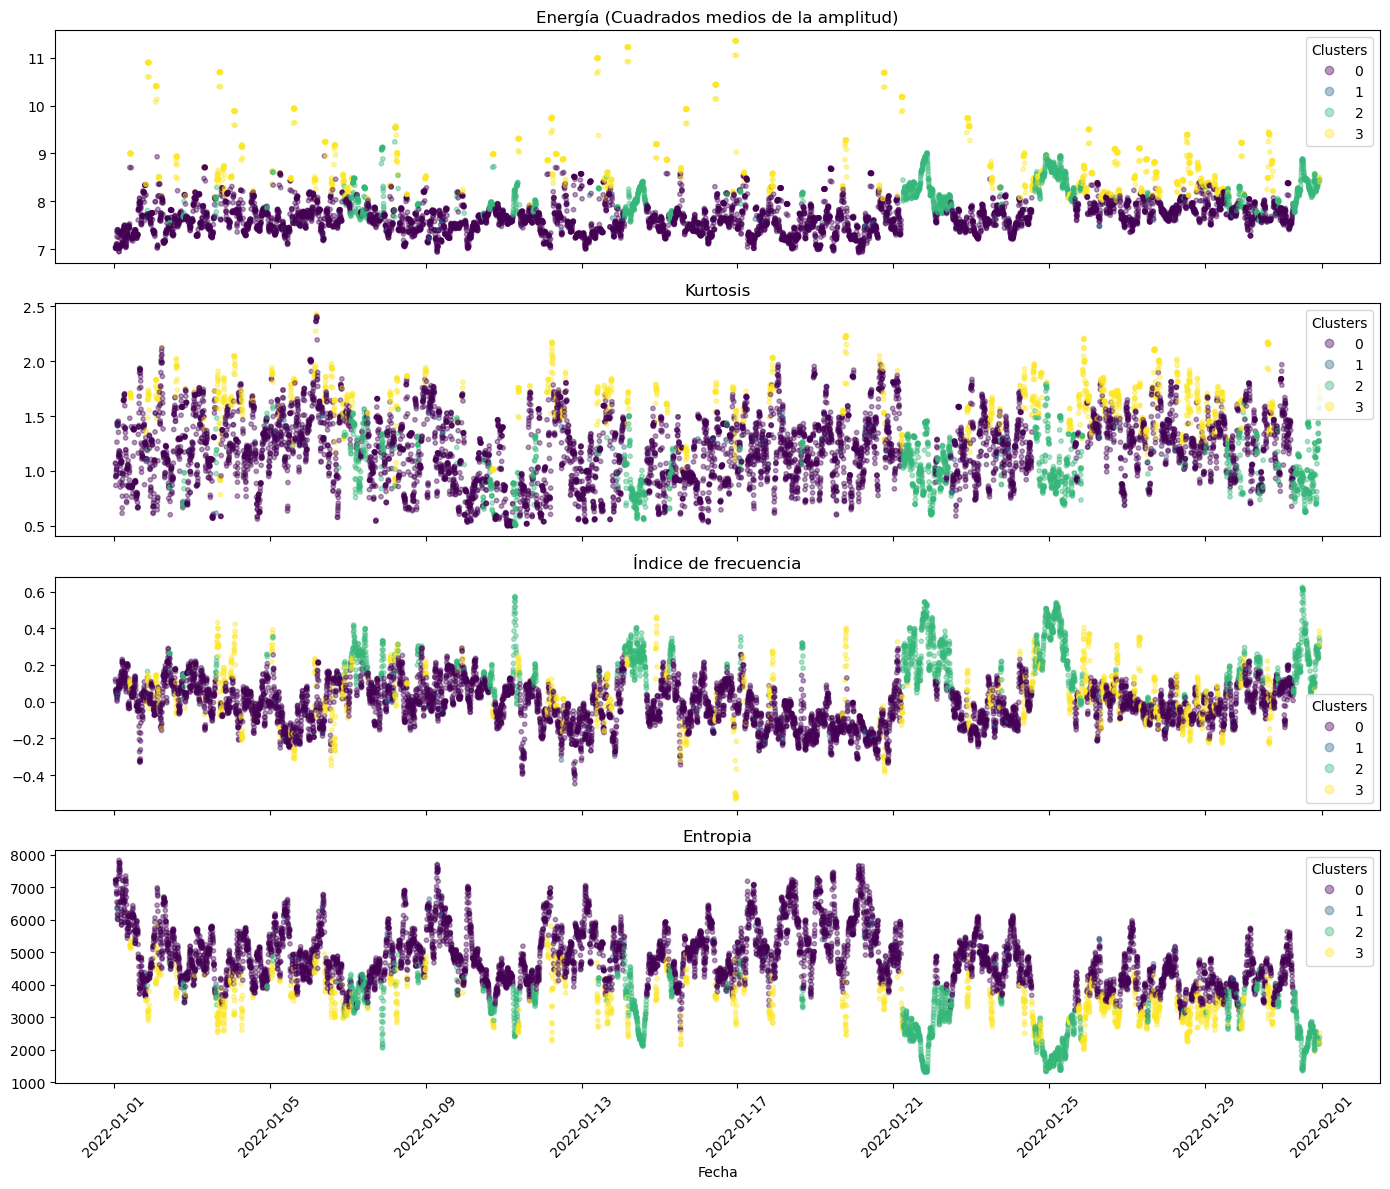

In [32]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(observed_data['timestamp'], observed_data['energy_mobile_mean'], c=observed_data['labels'], cmap='viridis', s=10, alpha=0.4)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(observed_data['timestamp'], observed_data['kurtosis_mobile_mean'], c=observed_data['labels'], cmap='viridis', s=10, alpha=0.4)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(observed_data['timestamp'], observed_data['frequency_index_mobile_mean'], c=observed_data['labels'], cmap='viridis', s=10, alpha=0.4)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(observed_data['timestamp'], observed_data['entropy_mobile_mean'], c=observed_data['labels'], cmap='viridis', s=10, alpha=0.4)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")

plt.xticks(rotation=45)
plt.tight_layout()

We can observe that the clustering is capturing the interested behavior, the group 2 seems to be the state representing the increased activity in the Popocatepetl volcano

## Identify outliers

In [54]:
km_model

KMeans(n_clusters=4, random_state=42)

In [55]:
distances = km_model.transform(Z)
clustering_data['distance_to_centroid'] = [distances[i, label] for i, label in enumerate(km_model.labels_)]

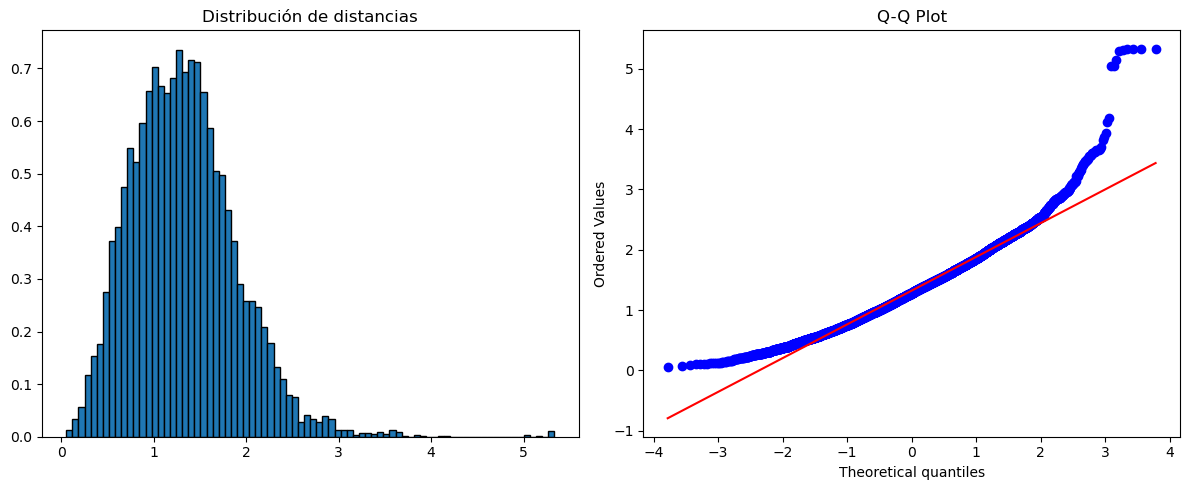

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma
axes[0].hist(clustering_data['distance_to_centroid'], bins=80, density=True, edgecolor='black')
axes[0].set_title('Distribución de distancias')

# Q-Q plot
stats.probplot(clustering_data['distance_to_centroid'], plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

In [57]:
# Rango de valores observados
np.min(clustering_data['distance_to_centroid']),np.max(clustering_data['distance_to_centroid'])

# Cálculo de cuartiles y cota superior de valores
Q1 = clustering_data['distance_to_centroid'].quantile(0.25)
Q3 = clustering_data['distance_to_centroid'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 3*IQR

# Clasificamos los valores observados como típicos y atípicos
clustering_data['outliers'] = clustering_data['distance_to_centroid'] > upper


## Forecast for next months

In [58]:
features_df_pred = features_df[(features_df['timestamp']<"2025-01-01") & (features_df['timestamp']>="2022-02-01")]

clustering_data_pred = features_df_pred[
    [
        'energy_mobile_mean',
        'kurtosis_mobile_mean',
        'frequency_index_mobile_mean',
        'entropy_mobile_mean'
    ]
]

# Drop rows with missing values
clustering_data_pred.isna().sum()

energy_mobile_mean             0
kurtosis_mobile_mean           0
frequency_index_mobile_mean    0
entropy_mobile_mean            0
dtype: int64

In [59]:
# Scale variables
X_pred = scaler.transform(clustering_data_pred)
# Transform the data to the new reducted space
Z_pred = pca.transform(X_pred)

c:\Users\javie\miniconda3\envs\estancia_popocatepetl\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [60]:
# Predict clusters for new data using the same centroids
labels_pred = km_model.predict(Z_pred)

### Outliers in new data

In [61]:
# Add labels and timestamp to the new dataframe
clustering_data_pred['timestamp'] = features_df_pred['timestamp']
clustering_data_pred['labels'] = labels_pred

distances_pred = km_model.transform(Z_pred)



clustering_data_pred['distance_to_centroid'] = [distances_pred[i, label] for i, label in enumerate(labels_pred)]
clustering_data_pred['outliers'] = clustering_data_pred['distance_to_centroid'] > upper


#clustering_data_all = pd.concat([clustering_data_run, clustering_data_rest], axis=0)
clustering_data_all = clustering_data_pred.copy()


# Optional: sort by timestamp
clustering_data_all = clustering_data_all.sort_values('timestamp')

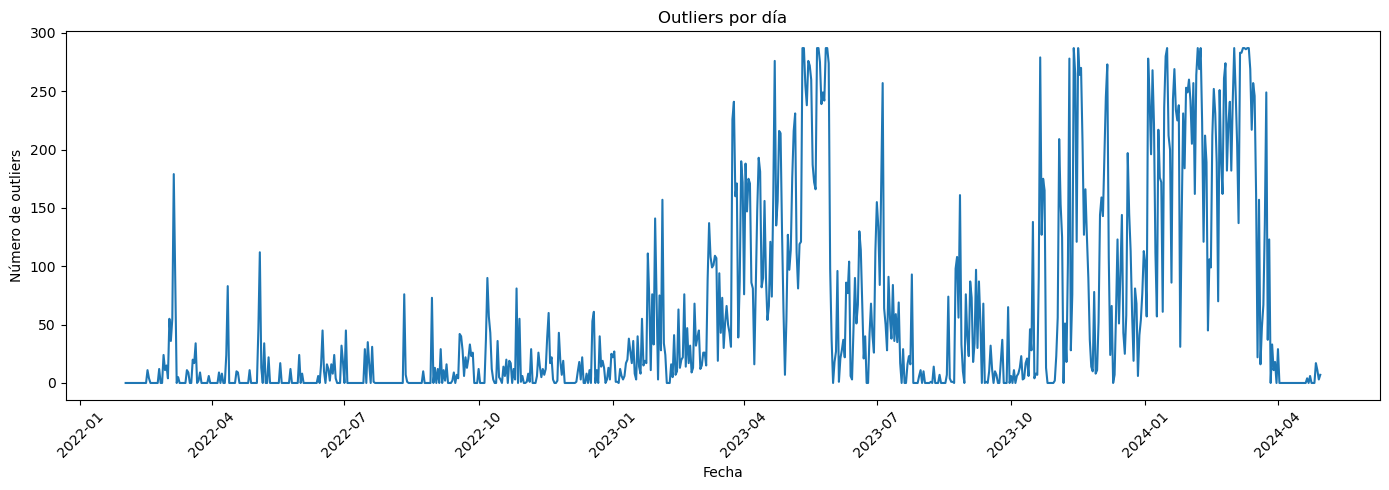

In [62]:
clustering_data_all['date'] = pd.to_datetime(clustering_data_all['timestamp']).dt.date

total_by_day = clustering_data_all.groupby('date').size()
outliers_by_day = (clustering_data_all[clustering_data_all['outliers'] == True]
                   .groupby('date')
                   .size())
# Reindex con todos los días, llenando con 0
outliers_by_day = outliers_by_day.reindex(total_by_day.index, fill_value=0)

outliers_by_day = outliers_by_day.reset_index()
outliers_by_day.columns = ['date', 'outliers']

plt.figure(figsize=(14, 5))
plt.plot(outliers_by_day['date'], outliers_by_day['outliers'])
plt.xlabel('Fecha')
plt.ylabel('Número de outliers')
plt.title('Outliers por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

una vez que se vaya a reentrenar el algoritmo con los outliers, hay que volver a correr el PCA y el K-Medias

Serie de tiempo de anomalias

Cada punto que tenemos está en un espacio de cuatro dimensiones

Devolver al espacio de una dimensión de la serie de tiempo original?

Cómo la regreso a una serie de tiempo de una variable?

Derivada de la distancia coseno de la serie de tiempo?

El promedio de las últimas diferencias, una media y una dispersión

Noción de anomalia

Cada punto en el tiempo es una dimensión

In [63]:
outliers_by_day.to_csv('../data/outliers/PCA_dim3_outliers.csv', index = False)

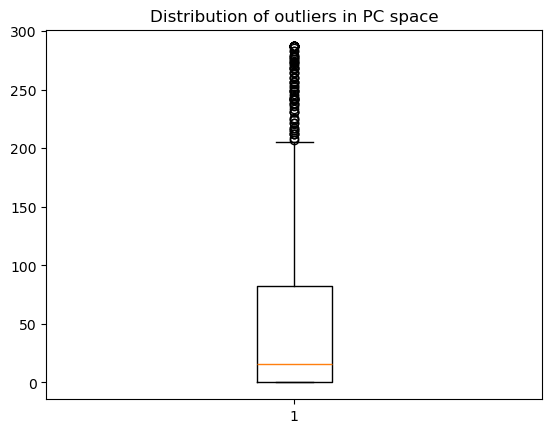

In [64]:
# Plot distribution of data
plt.title('Distribution of outliers in PC space')
plt.boxplot(outliers_by_day['outliers'])
plt.show()

In [65]:
# Cálculo de cuartiles y cota superior de valores
Q1_pred = outliers_by_day['outliers'].quantile(0.25)
Q3_pred = outliers_by_day['outliers'].quantile(0.75)
IQR_pred = Q3_pred - Q1_pred
upper_pred = Q3_pred + 2.5*IQR_pred

In [66]:
print(upper_pred)

288.75


## Retrain the model

In [68]:
date_reprocess = outliers_by_day[outliers_by_day['outliers'] > 200]['date'].iloc[0]

date_reprocess

datetime.date(2023, 3, 24)

In [69]:
from datetime import timedelta

features_df_rerun = features_df[features_df['timestamp'] <= pd.Timestamp(date_reprocess) + timedelta(days=1)]

In [132]:
features_df_rerun.tail()

,timestamp,energy,kurtosis,frecuency_index,entropy,frequency_index,energy_mobile_mean,kurtosis_mobile_mean,frequency_index_mobile_mean,entropy_mobile_mean
35296,2022-05-03 23:35:00,10.152867,0.533101,None,372.882117,1.386447,10.305004,0.530118,1.160464,344.608118
35297,2022-05-03 23:40:00,10.034944,0.559199,None,420.737492,1.327240,10.240232,0.533679,1.151212,361.671388
35298,2022-05-03 23:45:00,9.893652,0.519213,None,480.549191,1.263421,10.156998,0.533571,1.136936,384.076035
35299,2022-05-03 23:50:00,9.826691,0.497112,None,511.424428,1.251089,10.084959,0.529283,1.124651,406.264841
35300,2022-05-03 23:55:00,9.789176,0.486118,None,529.850443,1.201390,10.045375,0.522428,1.180568,423.554725


In [70]:
# Filter the first eleven observations
features_df_rerun = features_df_rerun.dropna(subset=['energy_mobile_mean'])
features_df_rerun.head()

,timestamp,energy,kurtosis,frecuency_index,entropy,frequency_index,energy_mobile_mean,kurtosis_mobile_mean,frequency_index_mobile_mean,entropy_mobile_mean
10,2022-01-01 00:55:00,6.939812,0.711175,None,7546.761724,0.088087,7.189824,1.016756,0.002807,6566.963119
11,2022-01-01 01:00:00,7.223312,1.604005,None,6466.796551,0.406264,7.202035,1.135282,0.040282,6541.763823
12,2022-01-01 01:05:00,7.226848,1.593019,None,6412.502725,0.412137,7.217582,1.225977,0.087732,6484.417105
13,2022-01-01 01:10:00,6.961643,0.591916,None,7359.259713,0.072474,7.214921,1.221882,0.091360,6501.124913
14,2022-01-01 01:15:00,6.911538,0.566936,None,7642.527056,-0.028144,7.209869,1.217271,0.082832,6542.602102


In [71]:
# Take descriptive variables
X_rerun = features_df_rerun[["energy_mobile_mean",	"kurtosis_mobile_mean",	
                         "frequency_index_mobile_mean", "entropy_mobile_mean"]].to_numpy()

print(X_rerun.shape)

(125038, 4)


In [72]:
X_rerun

array([[ 7.18982353e+00,  1.01675610e+00,  2.80678919e-03,
         6.56696312e+03],
       [ 7.20203479e+00,  1.13528158e+00,  4.02816503e-02,
         6.54176382e+03],
       [ 7.21758234e+00,  1.22597677e+00,  8.77315784e-02,
         6.48441711e+03],
       ...,
       [ 1.04535896e+01,  2.06339282e+00, -6.59639202e-01,
         7.61380533e+02],
       [ 1.03514052e+01,  2.06541503e+00, -6.30810952e-01,
         7.73754540e+02],
       [ 1.02041170e+01,  2.08143998e+00, -6.03483199e-01,
         7.88450585e+02]])

In [73]:
# Scale variables
scaler = StandardScaler().fit(X_rerun)
X_rerun = scaler.transform(X_rerun)

### PCA

In [74]:
# Train a PCA model
pcs_2 = PCA(n_components=4).fit(X_rerun)

# Report PCA summary
pcsSummary_2 = pd.DataFrame({'Standard deviation': np.sqrt(pcs_2.explained_variance_),
                           'Proportion of variance': pcs_2.explained_variance_ratio_,
                           'Cumulative variance': np.cumsum(pcs_2.explained_variance_ratio_)})

pcsSummary_2 = pcsSummary_2.transpose()
pcsSummary_2.columns = ['PC'+str(ind) for ind in range(1, 5)]
pcsSummary_2.round(3)

,PC1,PC2,PC3,PC4
Standard deviation,1.523,0.968,0.774,0.378
Proportion of variance,0.580,0.234,0.150,0.036
Cumulative variance,0.580,0.814,0.964,1.000


In [115]:
# See the weights for each PC
pcsComponents_2 = pd.DataFrame(pcs.components_.transpose(),
                             columns=['PC'+str(ind) for ind in range(1, 5)],
                             index= variables)

pcsComponents_2

,PC1,PC2,PC3,PC4
energy_mobile_mean,0.622870,0.096867,-0.299516,0.716199
kurtosis_mobile_mean,0.198621,0.861159,0.457580,-0.097850
frequency_index_mobile_mean,0.436324,-0.498516,0.749067,0.001221
entropy_mobile_mean,-0.618227,0.022427,0.373910,0.691002


(125038, 3)


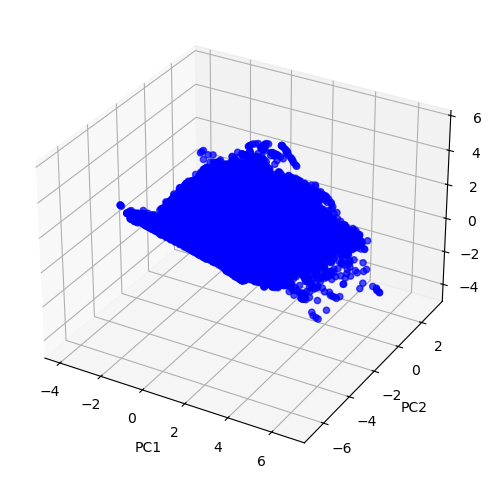

In [75]:
# Create a PCA object and train it
pca_2 = PCA(n_components=3).fit(X_rerun)
# Transform the data to the new reducted space
Z_rerun = pca_2.transform(X_rerun)
print(Z_rerun.shape)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Z_rerun[:, 0], Z_rerun[:, 1], Z_rerun[:, 2], c='b', s=20, alpha=0.7)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.grid(True)
plt.show()

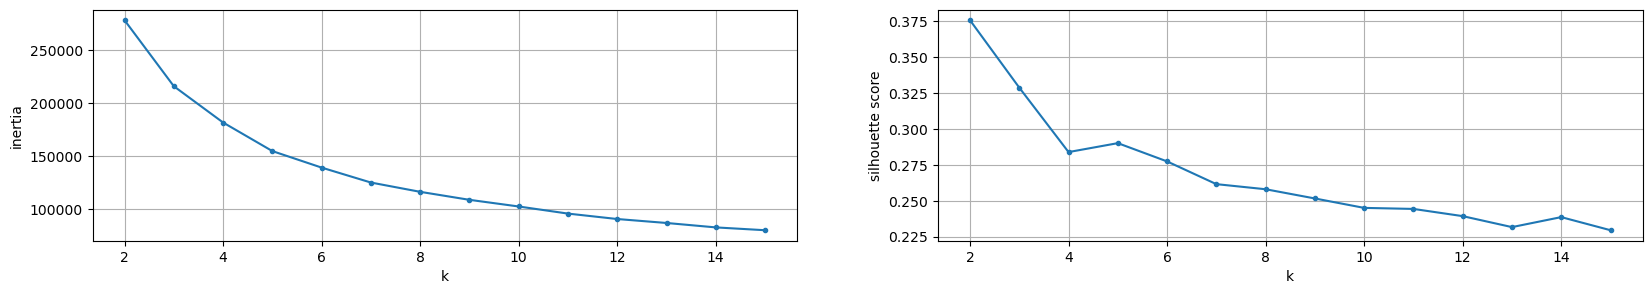

In [76]:
# Try with different number of groups
inertia = []
silh = []
k_s = np.arange(2, 16)
for k in k_s:
  km_model_rerun = KMeans(n_clusters=k).fit(Z_rerun)
  inertia.append(km_model_rerun.inertia_)
  silh.append(silhouette_score(Z_rerun, km_model_rerun.labels_))

# Plot results
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.plot(k_s, inertia, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('inertia')
plt.subplot(1, 2, 2)
plt.plot(k_s, silh, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.show()

In [126]:
# Run KMeans multiple times and find the most frequent label for each data point

n_iterations = 1000  # Number of times to run KMeans
n_clusters = 5

# Store labels from each iteration
all_labels = np.zeros((n_iterations, len(Z_rerun)), dtype=int)

# Run KMeans multiple times (without fixed random_state to get different initializations)
for i in range(n_iterations):
    km_temp = KMeans(n_clusters=n_clusters, random_state=None, n_init=10).fit(Z_rerun)
    all_labels[i, :] = km_temp.labels_
    if (i + 1) % 100 == 0:
        print(f"Completed iteration {i + 1}/{n_iterations}")

# Find the most frequent label for each data point
most_frequent_labels = np.zeros(len(Z_rerun), dtype=int)
label_frequencies = np.zeros(len(Z_rerun))
label_consistency = np.zeros(len(Z_rerun))

for point_idx in range(len(Z_rerun)):
    labels_for_point = all_labels[:, point_idx]
    # Get the most common label
    counts = np.bincount(labels_for_point, minlength=n_clusters)
    most_frequent_labels[point_idx] = np.argmax(counts)
    # Calculate frequency and consistency
    label_frequencies[point_idx] = np.max(counts) / n_iterations
    label_consistency[point_idx] = (np.max(counts) - np.sort(counts)[-2]) / n_iterations if n_clusters > 1 else 1.0

print(f"\nLabel frequency statistics:")
print(f"Mean frequency: {label_frequencies.mean():.3f}")
print(f"Min frequency: {label_frequencies.min():.3f}")
print(f"Max frequency: {label_frequencies.max():.3f}")
print(f"\nLabel consistency statistics:")
print(f"Mean consistency: {label_consistency.mean():.3f}")

# Use the most frequent labels as the final clustering result
km_model_rerun = KMeans(n_clusters=n_clusters, random_state=42).fit(Z_rerun)
km_model_rerun.labels_ = most_frequent_labels

Completed iteration 100/1000
Completed iteration 200/1000
Completed iteration 300/1000
Completed iteration 400/1000
Completed iteration 500/1000
Completed iteration 600/1000
Completed iteration 700/1000
Completed iteration 800/1000
Completed iteration 900/1000
Completed iteration 1000/1000

Label frequency statistics:
Mean frequency: 0.245
Min frequency: 0.208
Max frequency: 0.304

Label consistency statistics:
Mean consistency: 0.020


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


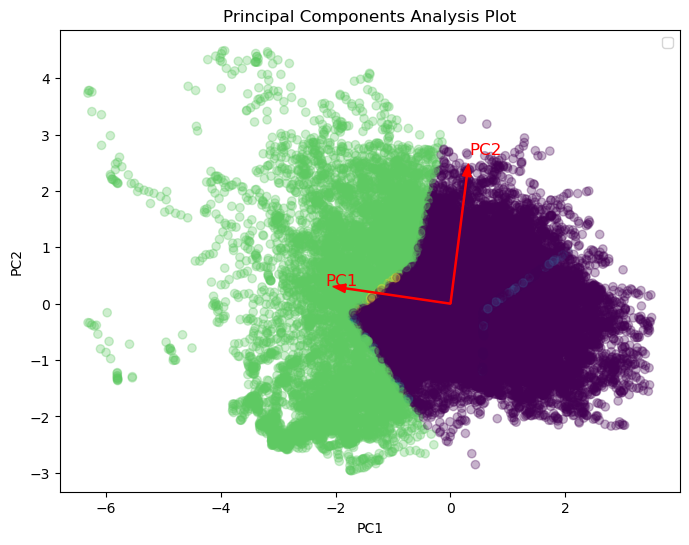

In [127]:
labels_rerun = km_model_rerun.labels_

plt.figure(figsize=(8, 6))
scatter = plt.scatter(Z_rerun[:, 0], Z_rerun[:, 1], c=labels_rerun, cmap='viridis', alpha=0.3)
#plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='+')
# Plot principal component axes
origin = np.mean(Z[:, :2], axis=0)
for i, (vec, var) in enumerate(zip(pca_2.components_[:2], pca_2.explained_variance_ratio_[:2])):
    plt.arrow(origin[0], origin[1], vec[0]*3, vec[1]*3, color='red', width=0.02, head_width=0.15, length_includes_head=True)
    plt.text(origin[0] + vec[0]*3.2, origin[1] + vec[1]*3.2, f'PC{i+1}', color='red', fontsize=12)
plt.title('Principal Components Analysis Plot')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

In [128]:
# Create a dataframe with the clustering data
clustering_data_rerun = pd.DataFrame(Z_rerun, columns= ['PC1', 'PC2'])
clustering_data_rerun['labels'] = km_model_rerun.labels_
km_model_rerun.cluster_centers_ = clustering_data_rerun.groupby('labels')[['PC1','PC2']].mean().values

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


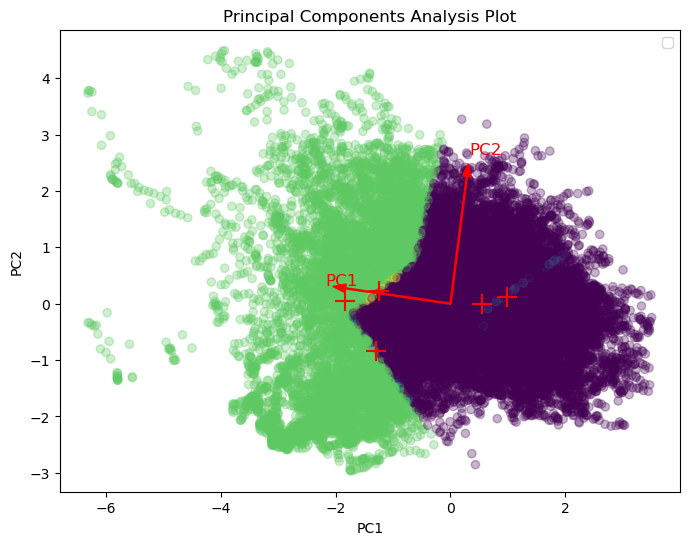

In [129]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(Z_rerun[:, 0], Z_rerun[:, 1], c=labels_rerun, cmap='viridis', alpha=0.3)
plt.scatter(km_model_rerun.cluster_centers_[:, 0], km_model_rerun.cluster_centers_[:, 1], c='red', s=200, marker='+')
# Plot principal component axes
origin = np.mean(Z[:, :2], axis=0)
for i, (vec, var) in enumerate(zip(pca_2.components_[:2], pca_2.explained_variance_ratio_[:2])):
    plt.arrow(origin[0], origin[1], vec[0]*3, vec[1]*3, color='red', width=0.02, head_width=0.15, length_includes_head=True)
    plt.text(origin[0] + vec[0]*3.2, origin[1] + vec[1]*3.2, f'PC{i+1}', color='red', fontsize=12)
plt.title('Principal Components Analysis Plot')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

In [130]:
clustering_data_rerun[['labels','PC1']].groupby('labels').count()

,PC1
labels,
0,26101
1,176
2,23
3,7785
4,44


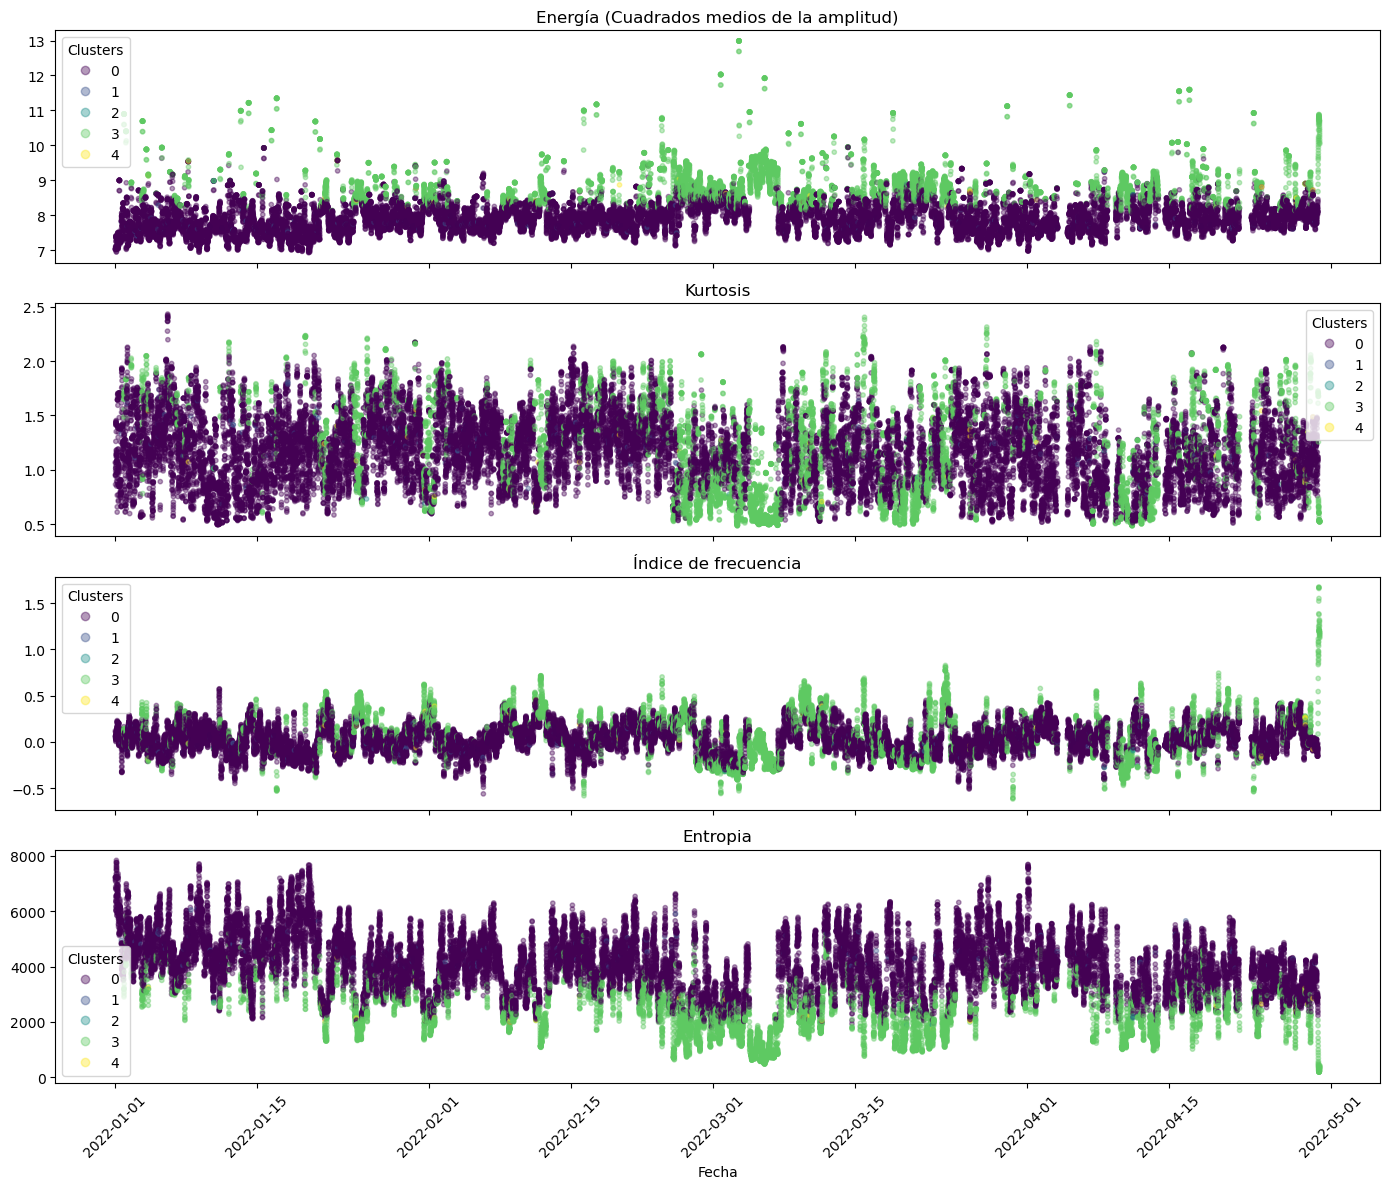

In [131]:
data_rerun = features_df_rerun[["energy_mobile_mean",	"kurtosis_mobile_mean",	
                         "frequency_index_mobile_mean", "entropy_mobile_mean"]].to_numpy()

# Create a dataframe with the clustering data including the timestamp column and labels
observed_data_rerun = pd.DataFrame(data_rerun, columns= variables)
observed_data_rerun['timestamp'] = features_df_rerun['timestamp']
observed_data_rerun['labels'] = km_model_rerun.labels_

observed_data_rerun = observed_data_rerun.dropna()

# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(observed_data_rerun['timestamp'], observed_data_rerun['energy_mobile_mean'], c=observed_data_rerun['labels'], cmap='viridis', s=10, alpha=0.4)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(observed_data_rerun['timestamp'], observed_data_rerun['kurtosis_mobile_mean'], c=observed_data_rerun['labels'], cmap='viridis', s=10, alpha=0.4)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(observed_data_rerun['timestamp'], observed_data_rerun['frequency_index_mobile_mean'], c=observed_data_rerun['labels'], cmap='viridis', s=10, alpha=0.4)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(observed_data_rerun['timestamp'], observed_data_rerun['entropy_mobile_mean'], c=observed_data_rerun['labels'], cmap='viridis', s=10, alpha=0.4)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")

plt.xticks(rotation=45)
plt.tight_layout()

Revisar para la tercera corrida de mayo de 2022
Solo hacer el clustering para los nuevos datos
Para los outliers detectados, correr el clustering y crear nuevas bolsas
